In [ ]:
# ============================================================
# INPUTS — edit these before running
# ============================================================
import os

os.environ["OMP_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "4"

# ---- Data folder ----
DATA_FOLDER = r"03_building_original\01_welton"
DATA_DIR    = os.path.join(os.getcwd(), DATA_FOLDER) if DATA_FOLDER else os.getcwd()

SEED   = 42
DEVICE = "cuda"

# ---- Mechanical property flags ----
USE_COMPRESSION    = True
USE_TENSION        = True
USE_SHEAR_Z        = True
USE_SHEAR_Y        = True
USE_MOMENT_TORSION = True
USE_MOMENT_Y       = True
USE_MOMENT_Z       = True
USE_DISPLACEMENT_T = False
USE_DISPLACEMENT_R = False

# ---- Beam feature flags ----
USE_GEOMETRY   = True    # include beam length + direction in local beam features
SYMMETRIC_GEOM = False   # fold |dir_x|,|dir_y| so mirror beams get identical features

# ---- Model architecture ----
HIDDEN  = 64
OUT_DIM = 32

# ---- Training ----
LR        = 1e-3
TAU       = 0.2
EPOCHS_V1 = 1000

# ---- kNN positive pairs ----
K_KNN          = 20
USE_ADJ_AS_POS = True
ADJ_WEIGHT     = 3

# ---- Global geometric features (make_global_beam_features) ----
COL_Z_THRESHOLD    = 1.0   # raw Z range (max_z - min_z) > this → classified as column
BRACING_H_THRESHOLD = 1.0  # raw horizontal span > this (combined with COL_Z_THRESHOLD) → bracing
GEOM_WEIGHT        = 20.0   # scale factor on all global geometric features (try 1.5–3.0)
BEAM_LENGTH_WEIGHT = 2.0   # extra multiplier applied specifically to beam length
                            # final weight = GEOM_WEIGHT * BEAM_LENGTH_WEIGHT (try 2.0–5.0)

# ---- GMM clustering ----
K_SELECT     = "manual"
K_SEARCH_MIN = 2
K_SEARCH_MAX = 15
K_LIST       = [120]
GMM_N_INIT   = 3
CATEGORIZE   = 1   # 0 → no split, cluster all together
                   # 1 → split into 3 types: column / girder / beam
                   # 2 → split into 4 types: column / girder / beam / bracing

# ---- Input files ----
INPUT_JSON           = os.path.join(DATA_DIR, "graph_line.json")
INPUT_NODES_CSV      = os.path.join(DATA_DIR, "nodes.csv")
INPUT_LINE_NODES_CSV = os.path.join(DATA_DIR, "line_nodes_beams.csv")
INPUT_LINE_EDGES_CSV = os.path.join(DATA_DIR, "line_edges.csv")

# ---- Output files ----
OUTPUT_EMB_V1            = os.path.join(DATA_DIR, "beam_embeddings_mp.csv")
OUTPUT_CLUSTER_PREFIX_V1 = "mp_gmm"

## Import

In [59]:
import random
import numpy as np
import torch


def set_seed(seed: int) -> None:
    """Set all random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)
print(f"Seed set to {SEED}")

Seed set to 42


In [60]:
import ast
import os
import json
import numpy as np
import pandas as pd


def load_from_json():
    """Load everything from INPUT_JSON (full path from config)."""
    with open(INPUT_JSON, "r", encoding="utf-8") as f:
        obj = json.load(f)

    nodes_xyz     = np.array(obj["original_nodes_xyz"], dtype=float)       # (n_nodes, 3)
    nodes_support = np.array(obj.get("original_nodes_support", []), dtype=int)  # (n_nodes,)
    line_nodes    = pd.DataFrame(obj["line_nodes_beams"])                   # n_beams rows
    line_edges    = pd.DataFrame(obj["line_edges"])                         # line graph edges

    meta = obj.get("meta", {})
    return meta, nodes_xyz, nodes_support, line_nodes, line_edges


def load_from_csv():
    """Load everything from CSV files (fallback when JSON unavailable)."""
    nodes = pd.read_csv(INPUT_NODES_CSV)
    # Sort by node_id to guarantee correct index alignment with point_indices
    if "node_id" in nodes.columns:
        nodes = nodes.sort_values("node_id").reset_index(drop=True)
    nodes_xyz     = nodes[["x", "y", "z"]].to_numpy(dtype=float)
    nodes_support = nodes["is_support"].to_numpy(dtype=int) if "is_support" in nodes.columns \
                    else np.zeros(len(nodes), dtype=int)

    line_nodes = pd.read_csv(INPUT_LINE_NODES_CSV)
    line_edges = pd.read_csv(INPUT_LINE_EDGES_CSV)

    meta = {}
    return meta, nodes_xyz, nodes_support, line_nodes, line_edges


## Helpers

In [ ]:
import torch
from torch import nn
import torch.nn.functional as F
from torch_geometric.data import HeteroData
from torch_geometric.nn import HeteroConv, GATConv
from torch_geometric.utils import negative_sampling
from sklearn.preprocessing import StandardScaler


def normalize_xyz_to_unit(nodes_xyz: np.ndarray, line_nodes: pd.DataFrame):
    """Scale all xyz coordinates to [-1, 1] using the global bounding box of nodes_xyz.
    Returns (nodes_xyz_normalized, line_nodes).
    start/end/sx/sy/sz/ex/ey/ez are derived later by preprocess_line_nodes().
    """
    xyz_min = nodes_xyz.min(axis=0)
    xyz_max = nodes_xyz.max(axis=0)
    scale = xyz_max - xyz_min
    scale[scale == 0] = 1.0

    nodes_xyz_n = (nodes_xyz - xyz_min) / scale * 2.0 - 1.0
    return nodes_xyz_n, line_nodes


def preprocess_line_nodes(nodes_xyz: np.ndarray, line_nodes: pd.DataFrame) -> pd.DataFrame:
    """Parse point_indices and derive geometry columns from normalized nodes_xyz.

    Adds to line_nodes (copy):
      _point_indices : list[list[int]]  — all node indices along each beam
      start / end    : int              — first / last node index
      sx,sy,sz       : float            — start node coords (normalized)
      ex,ey,ez       : float            — end node coords   (normalized)
    """
    ln = line_nodes.copy()

    def _parse(v):
        if isinstance(v, str):
            return ast.literal_eval(v)
        return list(v)

    pt_idx = ln["point_indices"].apply(_parse)
    ln["_point_indices"] = pt_idx

    starts = pt_idx.apply(lambda x: int(x[0])).to_numpy(dtype=np.int64)
    ends   = pt_idx.apply(lambda x: int(x[-1])).to_numpy(dtype=np.int64)
    ln["start"] = starts
    ln["end"]   = ends

    xyz = nodes_xyz.astype(np.float64)
    ln["sx"] = xyz[starts, 0];  ln["sy"] = xyz[starts, 1];  ln["sz"] = xyz[starts, 2]
    ln["ex"] = xyz[ends,   0];  ln["ey"] = xyz[ends,   1];  ln["ez"] = xyz[ends,   2]

    return ln


def classify_beam_types(nodes_xyz_raw: np.ndarray, line_nodes: pd.DataFrame,
                        col_z_threshold: float,
                        bracing_h_threshold: float = None) -> pd.DataFrame:
    """Classify each beam as column (0), girder (1), beam (2), or bracing (3).

    Must be called BEFORE normalize_xyz_to_unit — uses raw Z coordinates.

    Rules (from structural engineering convention):
      Bracing : z_diff > col_z_threshold AND h_diff > bracing_h_threshold
                (diagonal member spanning both vertically and horizontally)
                Only classified when CATEGORIZE == 2.
      Column  : z_diff > col_z_threshold (and not bracing)
      Girder  : non-column/bracing whose point_indices shares at least one node with any column
      Beam    : non-column/bracing, no shared node with any column

    Adds 'beam_type' column (int: 0=column, 1=girder, 2=beam, 3=bracing) to a copy of line_nodes.
    """
    if bracing_h_threshold is None:
        bracing_h_threshold = BRACING_H_THRESHOLD

    def _parse(v):
        if isinstance(v, str):
            return ast.literal_eval(v)
        return list(v)

    ln = line_nodes.copy()
    pt_idx = ln["point_indices"].apply(_parse)
    n_beams = len(ln)
    types = np.full(n_beams, 2, dtype=int)   # default: beam (2)

    # Step 0 (CATEGORIZE == 2 only): classify bracings
    # bracing = large vertical span AND large horizontal span
    if CATEGORIZE == 2:
        for i, pt_list in enumerate(pt_idx):
            z_vals = [nodes_xyz_raw[int(idx), 2] for idx in pt_list]
            x_vals = [nodes_xyz_raw[int(idx), 0] for idx in pt_list]
            y_vals = [nodes_xyz_raw[int(idx), 1] for idx in pt_list]
            z_diff = max(z_vals) - min(z_vals)
            h_diff = np.sqrt((max(x_vals) - min(x_vals))**2 + (max(y_vals) - min(y_vals))**2)
            if z_diff > col_z_threshold and h_diff > bracing_h_threshold:
                types[i] = 3

    # Step 1: classify columns by raw Z range (skip bracings already assigned)
    for i, pt_list in enumerate(pt_idx):
        if types[i] != 2:
            continue
        z_vals = [nodes_xyz_raw[int(idx), 2] for idx in pt_list]
        if max(z_vals) - min(z_vals) > col_z_threshold:
            types[i] = 0

    # Step 2: collect all node indices belonging to columns
    column_nodes: set[int] = set()
    for i, pt_list in enumerate(pt_idx):
        if types[i] == 0:
            for idx in pt_list:
                column_nodes.add(int(idx))

    # Step 3: girders = non-columns/bracings that touch at least one column node
    for i, pt_list in enumerate(pt_idx):
        if types[i] != 2:
            continue
        for idx in pt_list:
            if int(idx) in column_nodes:
                types[i] = 1
                break

    ln["beam_type"] = types
    n_col     = int((types == 0).sum())
    n_girder  = int((types == 1).sum())
    n_beam    = int((types == 2).sum())
    n_bracing = int((types == 3).sum())
    if CATEGORIZE == 2:
        print(f"classify_beam_types: {n_col} columns, {n_girder} girders, {n_beam} beams, {n_bracing} bracings  (threshold={col_z_threshold})")
    else:
        print(f"classify_beam_types: {n_col} columns, {n_girder} girders, {n_beam} beams  (threshold={col_z_threshold})")
    return ln


# Map each mechanical property name to its input flag
_MECH_FLAG_MAP = [
    ("compression",    "USE_COMPRESSION"),
    ("tension",        "USE_TENSION"),
    ("shear_z",        "USE_SHEAR_Z"),
    ("shear_y",        "USE_SHEAR_Y"),
    ("moment_torsion", "USE_MOMENT_TORSION"),
    ("moment_y",       "USE_MOMENT_Y"),
    ("moment_z",       "USE_MOMENT_Z"),
    ("displacement_t", "USE_DISPLACEMENT_T"),
    ("displacement_r", "USE_DISPLACEMENT_R"),
]


def _active_mech_cols(line_nodes: pd.DataFrame) -> list[str]:
    """Return mechanical column names that are both flagged True and present in line_nodes."""
    return [
        col for col, flag_name in _MECH_FLAG_MAP
        if globals().get(flag_name, True) and col in line_nodes.columns
    ]


def make_beam_feature_matrix(line_nodes: pd.DataFrame, use_geometry: bool = USE_GEOMETRY) -> np.ndarray:
    """Build a numeric feature matrix X for beams.

    Mechanical features (up to 9D, controlled by USE_* flags):
      compression, tension, shear_z, shear_y, moment_torsion, moment_y, moment_z,
      displacement_t, displacement_r

    Optional local geometry features (4D):
      L (1D)          — full beam length (start→end, in normalized coords)
      dir_x/y/z (3D)  — unit direction vector (orientation only, no position)

    Note: midpoint coordinates are intentionally excluded — structural position is
    encoded topologically in make_global_beam_features instead.
    """
    cols = _active_mech_cols(line_nodes)
    if cols:
        X = line_nodes[cols].apply(pd.to_numeric, errors="coerce").fillna(0.0).to_numpy(dtype=float)
    else:
        X = np.zeros((len(line_nodes), 1), dtype=float)

    X = StandardScaler().fit_transform(X)

    if use_geometry:
        req = ["sx", "sy", "sz", "ex", "ey", "ez"]
        if all(r in line_nodes.columns for r in req):
            s = line_nodes[["sx", "sy", "sz"]].to_numpy(dtype=float)
            e = line_nodes[["ex", "ey", "ez"]].to_numpy(dtype=float)
            d = e - s
            L = np.linalg.norm(d, axis=1, keepdims=True) + 1e-12
            dir_unit = d / L

            if SYMMETRIC_GEOM:
                dir_feats = np.concatenate([np.abs(dir_unit[:, [0]]),
                                            np.abs(dir_unit[:, [1]]),
                                            dir_unit[:, [2]]], axis=1)
            else:
                dir_feats = dir_unit   # (n_beams, 3)

            # Length + direction only — midpoint coords removed
            X = np.concatenate([X, L, dir_feats], axis=1)

    return X


def build_hetero_data(nodes_xyz, nodes_support, line_nodes: pd.DataFrame, line_edges: pd.DataFrame):
    """Build a hetero graph. Requires preprocess_line_nodes() to have been called.

    Node features (6D): [x, y, z, is_support, degree_norm, hop_dist_norm]
    Beam features: mechanical (≤9D) [+ local geometry (4D)] + global topology (9D)
    Incidence edges: each beam connected to ALL its point_indices nodes.
    """
    n_nodes = nodes_xyz.shape[0]
    n_beams = len(line_nodes)

    sup     = nodes_support.reshape(-1, 1).astype(np.float32)
    deg     = compute_node_degree(n_nodes, line_nodes).reshape(-1, 1)
    hdist   = compute_hop_dist_to_support(n_nodes, nodes_support, line_nodes).reshape(-1, 1)
    deg_n   = deg   / (deg.max()   + 1e-6)
    hdist_n = hdist / (hdist.max() + 1e-6)
    node_x  = np.concatenate(
        [nodes_xyz.astype(np.float32), sup, deg_n.astype(np.float32), hdist_n.astype(np.float32)],
        axis=1,
    )

    beam_mech   = make_beam_feature_matrix(line_nodes, use_geometry=USE_GEOMETRY).astype(np.float32)
    beam_global = make_global_beam_features(nodes_xyz, nodes_support, line_nodes, line_edges)
    beam_x      = np.concatenate([beam_mech, beam_global], axis=1)

    # Incidence: beam ↔ ALL point_indices nodes
    src_node_list, dst_beam_list = [], []
    for beam_idx, pt_list in enumerate(line_nodes["_point_indices"]):
        for node_idx in pt_list:
            src_node_list.append(int(node_idx))
            dst_beam_list.append(beam_idx)
    src_node = np.array(src_node_list, dtype=np.int64)
    dst_beam = np.array(dst_beam_list, dtype=np.int64)

    edge_node_to_beam = torch.from_numpy(np.stack([src_node, dst_beam], axis=0))
    edge_beam_to_node = torch.from_numpy(np.stack([dst_beam, src_node], axis=0))

    src = line_edges["src_beam"].to_numpy(dtype=np.int64)
    dst = line_edges["dst_beam"].to_numpy(dtype=np.int64)
    edge_beam_to_beam = torch.from_numpy(np.stack([src, dst], axis=0))

    data = HeteroData()
    data["node"].x = torch.from_numpy(node_x)
    data["beam"].x = torch.from_numpy(beam_x)
    data["node", "inc", "beam"].edge_index     = edge_node_to_beam
    data["beam", "rev_inc", "node"].edge_index = edge_beam_to_node
    data["beam", "adj", "beam"].edge_index     = edge_beam_to_beam

    return data


class BeamEncoder(nn.Module):
    def __init__(self, node_in: int, beam_in: int, hidden: int = 64, out_dim: int = 32, num_layers: int = 3, dropout: float = 0.0):
        super().__init__()
        self.num_layers = num_layers
        self.dropout = dropout

        self.convs = nn.ModuleList()
        for layer in range(num_layers):
            in_node = node_in if layer == 0 else hidden
            in_beam = beam_in if layer == 0 else hidden
            heads = 4
            out_per_head = hidden // heads
            self.convs.append(
                HeteroConv(
                    {
                        ("beam", "rev_inc", "node"): GATConv((in_beam, in_node), out_per_head, heads=heads, concat=True, add_self_loops=False),
                        ("node", "inc", "beam"):     GATConv((in_node, in_beam), out_per_head, heads=heads, concat=True, add_self_loops=False),
                        ("beam", "adj", "beam"):     GATConv((in_beam, in_beam), out_per_head, heads=heads, concat=True, add_self_loops=True),
                    },
                    aggr="sum",
                )
            )

        self.proj = nn.Linear(hidden, out_dim)

    def forward(self, data):
        x_dict = {"node": data["node"].x, "beam": data["beam"].x}

        for conv in self.convs:
            x_dict = conv(x_dict, data.edge_index_dict)
            x_dict = {k: F.relu(v) for k, v in x_dict.items()}
            if self.dropout > 0:
                x_dict = {k: F.dropout(v, p=self.dropout, training=self.training) for k, v in x_dict.items()}

        z_beam = self.proj(x_dict["beam"])
        z_beam = F.normalize(z_beam, p=2, dim=1)
        return z_beam

In [ ]:
from collections import deque


def compute_node_degree(n_nodes: int, line_nodes: pd.DataFrame) -> np.ndarray:
    """Number of beams incident to each structural node (via _point_indices).
    Returns (n_nodes,) float array.
    """
    degree = np.zeros(n_nodes, dtype=np.float32)
    for pt_list in line_nodes["_point_indices"]:
        for idx in pt_list:
            degree[int(idx)] += 1.0
    return degree


def compute_hop_dist_to_support(n_nodes: int, nodes_support: np.ndarray,
                                 line_nodes: pd.DataFrame) -> np.ndarray:
    """BFS hop-distance to nearest support node, using consecutive pairs in _point_indices.
    Returns (n_nodes,) float array. Disconnected nodes get the max finite distance.
    """
    adj = [[] for _ in range(n_nodes)]
    for pt_list in line_nodes["_point_indices"]:
        for i in range(len(pt_list) - 1):
            s, e = int(pt_list[i]), int(pt_list[i + 1])
            adj[s].append(e)
            adj[e].append(s)

    dist = np.full(n_nodes, np.inf, dtype=np.float32)
    queue = deque()
    for i, is_sup in enumerate(nodes_support):
        if is_sup > 0:
            dist[i] = 0.0
            queue.append(i)

    while queue:
        u = queue.popleft()
        for v in adj[u]:
            if dist[v] == np.inf:
                dist[v] = dist[u] + 1.0
                queue.append(v)

    finite_vals = dist[np.isfinite(dist)]
    fallback = float(finite_vals.max()) if len(finite_vals) > 0 else 0.0
    dist[~np.isfinite(dist)] = fallback
    return dist


def compute_line_graph_degree(n_beams: int, line_edges: pd.DataFrame) -> np.ndarray:
    """Number of adjacent beams in the line graph for each beam.
    Two beams are adjacent if they share at least one structural node.
    Returns (n_beams,) float array.
    """
    degree = np.zeros(n_beams, dtype=np.float32)
    srcs = line_edges["src_beam"].to_numpy(dtype=np.int64)
    dsts = line_edges["dst_beam"].to_numpy(dtype=np.int64)
    np.add.at(degree, srcs, 1.0)
    np.add.at(degree, dsts, 1.0)
    return degree


def make_global_beam_features(nodes_xyz: np.ndarray, nodes_support: np.ndarray,
                               line_nodes: pd.DataFrame,
                               line_edges: pd.DataFrame) -> np.ndarray:
    """Topological and structural-role features for each beam.

    All features are StandardScaler-normalized then multiplied by GEOM_WEIGHT.
    Beam length additionally gets BEAM_LENGTH_WEIGHT on top of that.

    Feature layout (CATEGORIZE != 2, 9D):
      0  beam_hop_dist       — BFS hops from beam endpoints to nearest support
      1  cos_vertical        — |dir_z|: 1 = vertical column, 0 = horizontal beam
      2  is_column           — 1 if beam_type == 0
      3  is_girder           — 1 if beam_type == 1
      4  is_beam             — 1 if beam_type == 2
      5  beam_length         — Euclidean length start→end (scaled by GEOM_WEIGHT * BEAM_LENGTH_WEIGHT)
      6  line_graph_degree   — #adjacent beams sharing a node
      7  endpoint_degree_min — min(degree(start_node), degree(end_node))
      8  endpoint_degree_max — max(degree(start_node), degree(end_node))

    Feature layout (CATEGORIZE == 2, 10D): same as above with an extra column after is_beam:
      5  is_bracing          — 1 if beam_type == 3
      6  beam_length         — (index shifts by 1)
      7  line_graph_degree
      8  endpoint_degree_min
      9  endpoint_degree_max

    Requires classify_beam_types() and preprocess_line_nodes() to have been called
    (uses beam_type, start/end/sx/sy/sz/ex/ey/ez columns).
    """
    n_nodes = nodes_xyz.shape[0]
    n_beams = len(line_nodes)
    starts  = line_nodes["start"].to_numpy(dtype=np.int64)
    ends    = line_nodes["end"].to_numpy(dtype=np.int64)

    # ---- 0. Hop distance to support ----
    node_hop = compute_hop_dist_to_support(n_nodes, nodes_support, line_nodes)
    beam_hop = np.minimum(node_hop[starts], node_hop[ends]).reshape(-1, 1)

    # ---- 1. cos_vertical + beam_length ----
    req = ["sx", "sy", "sz", "ex", "ey", "ez"]
    if all(c in line_nodes.columns for c in req):
        s_arr    = line_nodes[["sx", "sy", "sz"]].to_numpy(dtype=np.float64)
        e_arr    = line_nodes[["ex", "ey", "ez"]].to_numpy(dtype=np.float64)
        d        = e_arr - s_arr
        L_vec    = np.linalg.norm(d, axis=1, keepdims=True) + 1e-12
        dir_unit = d / L_vec
        cos_v    = np.abs(dir_unit[:, 2]).reshape(-1, 1).astype(np.float32)
    else:
        cos_v = np.zeros((n_beams, 1), dtype=np.float32)
        L_vec = np.ones((n_beams, 1), dtype=np.float64)

    # ---- Structural type one-hot from classify_beam_types ----
    beam_type = line_nodes["beam_type"].to_numpy(dtype=np.int64)
    if CATEGORIZE == 2:
        # 4-type one-hot: [is_col, is_girder, is_beam, is_bracing]
        n_types = 4
    else:
        # 3-type one-hot: [is_col, is_girder, is_beam]
        n_types = 3
    type_onehot = np.zeros((n_beams, n_types), dtype=np.float32)
    type_onehot[np.arange(n_beams), np.clip(beam_type, 0, n_types - 1)] = 1.0

    # ---- Beam length (full start→end Euclidean distance) ----
    beam_length = L_vec.astype(np.float32)

    # ---- Line graph degree (adjacency count) ----
    lg_deg = compute_line_graph_degree(n_beams, line_edges).reshape(-1, 1)

    # ---- Endpoint node degree (min / max) ----
    node_deg = compute_node_degree(n_nodes, line_nodes)
    deg_min  = np.minimum(node_deg[starts], node_deg[ends]).reshape(-1, 1)
    deg_max  = np.maximum(node_deg[starts], node_deg[ends]).reshape(-1, 1)

    # ---- Assemble, normalize, apply weights ----
    feats = np.concatenate([beam_hop, cos_v, type_onehot, beam_length, lg_deg, deg_min, deg_max], axis=1)
    feats = StandardScaler().fit_transform(feats) * GEOM_WEIGHT
    # beam_length column index = 2 + n_types (after hop + cos_v + onehot)
    length_idx = 2 + n_types
    feats[:, length_idx] *= BEAM_LENGTH_WEIGHT   # extra boost for beam length

    return feats.astype(np.float32)

In [ ]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt


def build_knn_pos_edges_from_mech(line_nodes: pd.DataFrame, k: int = 10) -> torch.Tensor:
    # English comments only: build positive edges by kNN in mechanical feature space
    cols = _active_mech_cols(line_nodes)
    if cols:
        X = line_nodes[cols].apply(pd.to_numeric, errors="coerce").fillna(0.0).to_numpy(dtype=np.float32)
    else:
        X = np.zeros((len(line_nodes), 1), dtype=np.float32)

    X = StandardScaler().fit_transform(X)

    nbrs = NearestNeighbors(n_neighbors=k + 1, algorithm="auto").fit(X)
    idx = nbrs.kneighbors(X, return_distance=False)  # (n, k+1), includes self at idx[:,0]

    src = np.repeat(np.arange(X.shape[0]), k)
    dst = idx[:, 1:k+1].reshape(-1)  # skip self

    edge = torch.from_numpy(np.stack([src, dst], axis=0)).long()
    return edge


def build_adj_pos_edges(line_edges: pd.DataFrame) -> torch.Tensor:
    """Return beam-beam adjacency edges from the line graph as positive pairs."""
    src = line_edges["src_beam"].to_numpy(dtype=np.int64)
    dst = line_edges["dst_beam"].to_numpy(dtype=np.int64)
    return torch.from_numpy(np.stack([src, dst], axis=0)).long()


def _plot_ssl_training_curves(loss_history: list, gap_history: list) -> None:
    epochs = list(range(1, len(loss_history) + 1))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epochs, loss_history, color="#2196F3", linewidth=1.5)
    ax1.set_title("Contrastive Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.grid(True, linestyle="--", alpha=0.5)

    ax2.plot(epochs, gap_history, color="#4CAF50", linewidth=1.5)
    ax2.set_title("Pos–Neg Similarity Gap")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Gap")
    ax2.grid(True, linestyle="--", alpha=0.5)

    fig.suptitle("Self-supervised Training Metrics", fontsize=13)
    fig.tight_layout()
    plt.show()


def train_contrastive_beam_embeddings(data, pos_edge_knn, hidden=HIDDEN, out_dim=OUT_DIM, epochs=EPOCHS_V1, lr=LR, tau=TAU, device=DEVICE):
    # English comments only: contrastive training using kNN positives (mechanics), random negatives
    set_seed(SEED)   # fix model init + negative_sampling randomness
    data = data.to(device)
    pos_edge_knn = pos_edge_knn.to(device)

    node_in = data["node"].x.shape[1]
    beam_in = data["beam"].x.shape[1]

    model = BeamEncoder(node_in=node_in, beam_in=beam_in, hidden=hidden, out_dim=out_dim).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    loss_history, gap_history = [], []

    for ep in range(1, epochs + 1):
        model.train()
        opt.zero_grad()

        z = model(data)  # (n_beams, d)
        src, dst = pos_edge_knn[0], pos_edge_knn[1]
        pos_sim = (z[src] * z[dst]).sum(dim=1) / tau

        neg_edge = negative_sampling(
            edge_index=pos_edge_knn,
            num_nodes=z.size(0),
            num_neg_samples=pos_edge_knn.size(1),
        )
        nsrc, ndst = neg_edge[0], neg_edge[1]
        neg_sim = (z[nsrc] * z[ndst]).sum(dim=1) / tau

        loss = -torch.log(torch.sigmoid(pos_sim) + 1e-12).mean() - torch.log(1 - torch.sigmoid(neg_sim) + 1e-12).mean()
        loss.backward()
        opt.step()

        gap = pos_sim.mean().item() - neg_sim.mean().item()
        loss_history.append(loss.item())
        gap_history.append(gap)

        if ep % 50 == 0 or ep == 1:
            print(f"Epoch {ep:04d} | loss={loss.item():.4f} | gap={gap:.3f}")

    _plot_ssl_training_curves(loss_history, gap_history)

    model.eval()
    with torch.no_grad():
        z = model(data).detach().cpu().numpy()
    return z, model


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score


def run_gmm_fixed_k(Xg, k, seed=SEED, cov_type="diag"):
    """Fit a fixed-K GMM and return labels + probabilities."""
    gmm = GaussianMixture(
        n_components=k,
        covariance_type=cov_type,
        random_state=seed,
        reg_covar=1e-6,
        n_init=GMM_N_INIT,
    )
    gmm.fit(Xg)
    labels = gmm.predict(Xg)
    probs = gmm.predict_proba(Xg)
    bic = gmm.bic(Xg)
    aic = gmm.aic(Xg)
    return gmm, labels, probs, bic, aic


def find_optimal_k_silhouette(Xg, k_min=K_SEARCH_MIN, k_max=K_SEARCH_MAX,
                               cov_type="diag", seed=SEED):
    """
    Fit GMMs for K in [k_min, k_max] and return the K that maximises Silhouette score.
    Silhouette measures cluster compactness and separation; it naturally prefers fewer,
    well-separated groups compared to BIC.
    Returns (best_k, sil_scores_dict).
    """
    best_k, best_sil = k_min, -np.inf
    sil_scores = {}
    k_upper = min(k_max, len(Xg) - 1)

    print(f"Searching optimal K in [{k_min}, {k_upper}] by Silhouette score ({cov_type} covariance) ...")
    for k in range(k_min, k_upper + 1):
        gmm = GaussianMixture(
            n_components=k,
            covariance_type=cov_type,
            random_state=seed,
            reg_covar=1e-6,
            n_init=GMM_N_INIT,
        )
        labels = gmm.fit_predict(Xg)
        if len(np.unique(labels)) < 2:
            continue
        sil = silhouette_score(Xg, labels)
        sil_scores[k] = sil
        marker = " ←" if sil > best_sil else ""
        print(f"  K={k:3d}  Silhouette={sil:.4f}{marker}")
        if sil > best_sil:
            best_sil = sil
            best_k = k

    print(f"→ Optimal K = {best_k}  (Silhouette = {best_sil:.4f})")
    return best_k, sil_scores


def find_optimal_k_bic(Xg, k_min=K_SEARCH_MIN, k_max=K_SEARCH_MAX,
                       cov_type="diag", seed=SEED):
    """
    Fit GMMs for K in [k_min, k_max] and return the K that minimises BIC.
    Returns (best_k, bic_scores_dict).
    """
    best_k, best_bic = k_min, np.inf
    bic_scores = {}

    print(f"Searching optimal K in [{k_min}, {k_max}] by BIC ({cov_type} covariance) ...")
    for k in range(k_min, k_max + 1):
        gmm = GaussianMixture(
            n_components=k,
            covariance_type=cov_type,
            random_state=seed,
            reg_covar=1e-6,
            n_init=GMM_N_INIT,
        )
        gmm.fit(Xg)
        bic = gmm.bic(Xg)
        bic_scores[k] = bic
        marker = " ←" if bic < best_bic else ""
        print(f"  K={k:3d}  BIC={bic:10.2f}{marker}")
        if bic < best_bic:
            best_bic = bic
            best_k = k

    print(f"→ Optimal K = {best_k}  (BIC = {best_bic:.2f})")
    return best_k, bic_scores


def _resolve_k_list(Xg, k_list, k_select, cov_type="diag"):
    """
    Return the list of K values to cluster with, based on K_SELECT:
      "silhouette" → auto search, picks K maximising Silhouette score (fewer clusters)
      "bic"        → auto search, picks K minimising BIC
      "manual"     → use k_list as-is
    """
    if k_select == "silhouette":
        best_k, _ = find_optimal_k_silhouette(Xg, cov_type=cov_type)
        return [best_k]
    elif k_select == "bic":
        best_k, _ = find_optimal_k_bic(Xg, cov_type=cov_type)
        return [best_k]
    else:  # "manual"
        return k_list


def _run_per_type_gmm(Zs, beam_types, K_total, k_select, cov_type="diag", seed=SEED):
    """Run GMM separately per structural type (0=column, 1=girder, 2=beam, 3=bracing).

    K allocation:
      manual     — K split proportionally by type count (rounded, min 1 per type)
      silhouette — auto K per type via silhouette search
      bic        — auto K per type via BIC search

    Type 3 (bracing) is only present when CATEGORIZE == 2.
    Cluster IDs are offset so types never share a cluster index.
    Returns:
      global_labels : (n_beams,) int  — cluster index for each beam
      global_probs  : (n_beams, K_actual) float  — GMM soft probabilities
    """
    TYPE_NAMES = {0: "column", 1: "girder", 2: "beam", 3: "bracing"}
    type_list  = [0, 1, 2, 3] if CATEGORIZE == 2 else [0, 1, 2]
    n_total = len(Zs)
    results = {}
    cluster_offset = 0

    for t in type_list:
        mask = beam_types == t
        n_t = int(mask.sum())
        if n_t == 0:
            continue
        Zt = Zs[mask]

        if k_select == "silhouette":
            K_t, _ = find_optimal_k_silhouette(Zt, seed=seed, cov_type=cov_type)
        elif k_select == "bic":
            K_t, _ = find_optimal_k_bic(Zt, seed=seed, cov_type=cov_type)
        else:
            K_t = max(1, round(K_total * n_t / n_total))

        K_t = max(1, min(K_t, n_t))
        print(f"  type={TYPE_NAMES[t]} (n={n_t})  K={K_t}")
        _, labels_t, probs_t, bic_t, aic_t = run_gmm_fixed_k(Zt, K_t, seed=seed, cov_type=cov_type)
        print(f"    BIC={bic_t:.2f}  AIC={aic_t:.2f}")
        results[t] = (mask, labels_t, probs_t, K_t, cluster_offset)
        cluster_offset += K_t

    K_actual = cluster_offset
    global_labels = np.zeros(n_total, dtype=int)
    global_probs  = np.zeros((n_total, K_actual), dtype=float)

    for t, (mask, labels_t, probs_t, K_t, offset) in results.items():
        rows = np.where(mask)[0]
        global_labels[rows] = labels_t + offset
        global_probs[rows[:, np.newaxis], np.arange(offset, offset + K_t)[np.newaxis, :]] = probs_t

    return global_labels, global_probs


def export_clusters(prefix, line_nodes, labels, probs):
    """Save clustering assignment to DATA_DIR/beam_clusters_{prefix}.csv.

    Expands each merged beam back to its original source beams using the
    source_beam_ids column, so output length equals the total number of
    original beam elements. Rows are sorted by source_beam_id.

    Output columns: source_beam_id, beam_id, element_id, beam_type, cluster, p0..pK-1
    """
    def _parse_source_ids(v):
        if isinstance(v, str):
            return ast.literal_eval(v)
        return list(v)

    has_element_id = "element_id" in line_nodes.columns
    has_beam_type  = "beam_type"  in line_nodes.columns
    TYPE_NAMES = {0: "column", 1: "girder", 2: "beam", 3: "bracing"}

    rows = []
    for i in range(len(line_nodes)):
        row        = line_nodes.iloc[i]
        beam_id    = int(row["beam_id"])
        source_ids = _parse_source_ids(row["source_beam_ids"])
        cluster    = int(labels[i])
        prob_vals  = probs[i]

        for src_id in source_ids:
            entry = {"source_beam_id": int(src_id), "beam_id": beam_id}
            if has_element_id:
                entry["element_id"] = row["element_id"]
            if has_beam_type:
                t = int(row["beam_type"])
                entry["beam_type"]      = t
                entry["beam_type_name"] = TYPE_NAMES.get(t, "unknown")
            entry["cluster"] = cluster
            for j, p in enumerate(prob_vals):
                entry[f"p{j}"] = p
            rows.append(entry)

    out_df = pd.DataFrame(rows).sort_values("source_beam_id").reset_index(drop=True)
    path = os.path.join(DATA_DIR, f"beam_clusters_{prefix}.csv")
    out_df.to_csv(path, index=False)
    print(f"Saved: {path}  ({len(out_df)} source beams from {len(line_nodes)} merged beams)")
    return out_df

In [ ]:
import matplotlib.pyplot as plt


def _plot_gmm_diagnostics(labels: np.ndarray, probs: np.ndarray, k: int,
                           bic: float = None, aic: float = None) -> None:
    clusters, counts = np.unique(labels, return_counts=True)
    max_probs = probs.max(axis=1)  # soft-assignment confidence per beam

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.bar(clusters, counts, color="#9C27B0", alpha=0.8, edgecolor="white", linewidth=0.5)
    ax1.set_title(f"Cluster Size Distribution (K={k})")
    ax1.set_xlabel("Cluster")
    ax1.set_ylabel("Number of Beams")
    ax1.grid(True, axis="y", linestyle="--", alpha=0.5)

    ax2.hist(max_probs, bins=30, color="#FF5722", alpha=0.8, edgecolor="white")
    ax2.axvline(max_probs.mean(), color="#222222", linestyle="--", linewidth=1.5,
                label=f"mean = {max_probs.mean():.2f}")
    conf_title = "Soft-assignment Confidence"
    if bic is not None:
        conf_title += f"\nBIC={bic:.1f}  AIC={aic:.1f}"
    ax2.set_title(conf_title)
    ax2.set_xlabel("Max cluster probability per beam")
    ax2.set_ylabel("Count")
    ax2.legend()
    ax2.grid(True, axis="y", linestyle="--", alpha=0.5)

    fig.suptitle(f"GMM Diagnostics (K={k})", fontsize=13)
    fig.tight_layout()
    plt.show()


def unsup_mp_gmm_pipeline(K_list=K_LIST, prefer_json=True, device=DEVICE):
    set_seed(SEED)   # fix all randomness for full pipeline reproducibility
    # ---- Load ----
    if prefer_json and os.path.exists(INPUT_JSON):
        meta, nodes_xyz, nodes_support, line_nodes, line_edges = load_from_json()
    else:
        meta, nodes_xyz, nodes_support, line_nodes, line_edges = load_from_csv()

    # ---- Classify beam types using RAW coordinates (before normalization) ----
    line_nodes = classify_beam_types(nodes_xyz, line_nodes, COL_Z_THRESHOLD)

    # ---- Normalize xyz to [-1, 1] ----
    nodes_xyz, line_nodes = normalize_xyz_to_unit(nodes_xyz, line_nodes)

    # ---- Parse point_indices and derive start/end/sx/sy/sz/ex/ey/ez ----
    line_nodes = preprocess_line_nodes(nodes_xyz, line_nodes)

    # ---- Build hetero graph ----
    data = build_hetero_data(nodes_xyz, nodes_support, line_nodes, line_edges)

    # ---- Build positive pairs: kNN (mechanical) ∪ adjacency (optional) ----
    pos_knn = build_knn_pos_edges_from_mech(line_nodes, k=K_KNN)
    if USE_ADJ_AS_POS:
        adj_pos = build_adj_pos_edges(line_edges)
        # Repeat adjacency edges ADJ_WEIGHT times to strengthen neighbor pull
        pos_knn = torch.cat([pos_knn, adj_pos.repeat(1, ADJ_WEIGHT)], dim=1)

    # ---- Train self-supervised message passing encoder ----
    Z, model = train_contrastive_beam_embeddings(
        data, pos_knn,
        hidden=HIDDEN, out_dim=OUT_DIM, epochs=EPOCHS_V1, lr=LR, tau=TAU,
        device=device,
    )

    # ---- Cluster embeddings ----
    Zs = StandardScaler().fit_transform(Z)
    beam_types = line_nodes["beam_type"].to_numpy(dtype=np.int64)

    emb_df = pd.DataFrame(Zs, columns=[f"z{i}" for i in range(Zs.shape[1])])
    emb_df.insert(0, "beam_id", line_nodes["beam_id"].to_numpy())
    emb_df.to_csv(OUTPUT_EMB_V1, index=False)
    print(f"Saved: {OUTPUT_EMB_V1}")

    # K_SELECT controls how K is chosen: "silhouette" | "bic" | "manual"
    ks = _resolve_k_list(Zs, K_list, k_select=K_SELECT, cov_type="diag")

    for k in ks:
        if CATEGORIZE >= 1:
            type_desc = "column+girder+beam+bracing" if CATEGORIZE == 2 else "column+girder+beam"
            print(f"\nPer-type GMM  K_total={k}:")
            labels_k, probs_k = _run_per_type_gmm(Zs, beam_types, k, K_SELECT)
            K_actual = probs_k.shape[1]
            print(f"K_total={k} → K_actual={K_actual}  ({type_desc} split)")
            _plot_gmm_diagnostics(labels_k, probs_k, K_actual)
        else:
            print(f"\nGlobal GMM  K={k}:")
            _, labels_k, probs_k, bic_k, aic_k = run_gmm_fixed_k(Zs, k, seed=SEED, cov_type="diag")
            K_actual = k
            print(f"K={K_actual}  BIC={bic_k:.2f}  AIC={aic_k:.2f}")
            _plot_gmm_diagnostics(labels_k, probs_k, K_actual, bic=bic_k, aic=aic_k)
        export_clusters(f"{OUTPUT_CLUSTER_PREFIX_V1}_k{K_actual}", line_nodes, labels_k, probs_k)

    return Zs, data


## Run

In [68]:
# run with massage passing
Zs, data = unsup_mp_gmm_pipeline()

classify_beam_types: 153 columns, 171 girders, 18 beams  (threshold=1.0)
Epoch 0001 | loss=4.0703 | gap=0.336
Epoch 0050 | loss=1.2247 | gap=1.588
Epoch 0100 | loss=1.1214 | gap=1.724
Epoch 0150 | loss=1.0478 | gap=1.836
Epoch 0200 | loss=1.0073 | gap=1.912
Epoch 0250 | loss=0.9571 | gap=2.021
Epoch 0300 | loss=0.9412 | gap=2.089
Epoch 0350 | loss=0.9183 | gap=2.152
Epoch 0400 | loss=0.9075 | gap=2.197
Epoch 0450 | loss=0.8954 | gap=2.246
Epoch 0500 | loss=0.8805 | gap=2.278
Epoch 0550 | loss=0.8764 | gap=2.297
Epoch 0600 | loss=0.8783 | gap=2.305
Epoch 0650 | loss=0.8730 | gap=2.324
Epoch 0700 | loss=0.8777 | gap=2.318
Epoch 0750 | loss=0.8590 | gap=2.356
Epoch 0800 | loss=0.8598 | gap=2.363
Epoch 0850 | loss=0.8584 | gap=2.379
Epoch 0900 | loss=0.8539 | gap=2.386
Epoch 0950 | loss=0.8494 | gap=2.396
Epoch 1000 | loss=0.8476 | gap=2.398
Saved: e:\Projects\26Spring_StructureGNN\structure_classification\04_shell\beam_embeddings_mp.csv

Global GMM  K=30:
K=30  BIC=34598.27  AIC=27124.23


## Visualization

In [115]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import plotly.graph_objects as go

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [116]:
# ---- Visualization: which cluster files to plot ----
CLUSTER_FILE         = os.path.join(DATA_DIR, "beam_clusters_mp_gmm_k50.csv")

### Functions

In [53]:
# -----------------------------
# IO helpers
# -----------------------------
def load_beam_clusters(filepath: str) -> pd.DataFrame:
    """Load clustering result csv (beam_id, start, end, cluster, p0..pK-1)."""
    df = pd.read_csv(filepath)

    req = {"beam_id", "cluster"}
    missing = req - set(df.columns)
    if missing:
        raise ValueError(f"{filepath} missing columns: {sorted(missing)}")

    df["beam_id"] = df["beam_id"].astype(int)
    df["cluster"] = df["cluster"].astype(int)
    return df


def load_line_nodes(filepath: str = INPUT_LINE_NODES_CSV) -> pd.DataFrame:
    """Load beam-node table exported from GH."""
    df = pd.read_csv(filepath)
    if "beam_id" not in df.columns:
        raise ValueError(f"{filepath} missing 'beam_id'")
    df["beam_id"] = df["beam_id"].astype(int)
    return df


def attach_geometry(cluster_df: pd.DataFrame, line_nodes: pd.DataFrame) -> pd.DataFrame:
    """Merge endpoints sx..ez into the cluster dataframe."""
    geom_cols = ["beam_id", "sx", "sy", "sz", "ex", "ey", "ez"]
    missing = [c for c in geom_cols if c not in line_nodes.columns]
    if missing:
        raise ValueError(f"line_nodes missing geometry columns: {missing}")
    return cluster_df.merge(line_nodes[geom_cols], on="beam_id", how="left")


In [54]:
# -----------------------------
# Align labels/probs to line_nodes ordering
# -----------------------------
def align_clusters_to_line_nodes(cluster_df: pd.DataFrame, line_nodes: pd.DataFrame):
    """
    Return:
      labels: (n_beams,) int array aligned to line_nodes beam_id order
      probs:  (n_beams, K) float array aligned to same order (or None if not present)
    """
    beam_ids = line_nodes["beam_id"].to_numpy(dtype=int)

    # label lookup
    lab_map = dict(zip(cluster_df["beam_id"].to_numpy(dtype=int), cluster_df["cluster"].to_numpy(dtype=int)))
    labels = np.array([lab_map[b] for b in beam_ids], dtype=int)

    # probability columns p0..pK-1 (optional)
    pcols = [c for c in cluster_df.columns if c.startswith("p")]
    probs = None
    if len(pcols) > 0:
        # Ensure sorted p0, p1, ...
        def _pidx(name: str) -> int:
            try:
                return int(name[1:])
            except Exception:
                return 10**9
        pcols = sorted(pcols, key=_pidx)

        prob_map = dict(zip(cluster_df["beam_id"].to_numpy(dtype=int), cluster_df[pcols].to_numpy(dtype=float)))
        probs = np.stack([prob_map[b] for b in beam_ids], axis=0)

    return labels, probs

In [55]:
def compute_Z2_from_line_nodes(line_nodes: pd.DataFrame) -> np.ndarray:
    """PCA-2D on standardized raw mechanical features."""
    X = make_beam_feature_matrix(line_nodes, use_geometry=False)
    Xs = StandardScaler().fit_transform(X)
    Z2 = PCA(n_components=2, random_state=SEED).fit_transform(Xs)
    return Z2


def compute_Z2_from_embeddings_csv(line_nodes: pd.DataFrame, emb_filepath: str = OUTPUT_EMB_V1) -> np.ndarray:
    """PCA-2D from learned embeddings (full path). Must align by beam_id."""
    emb = pd.read_csv(emb_filepath)
    if "beam_id" not in emb.columns:
        raise ValueError(f"{emb_filepath} missing 'beam_id'")
    emb["beam_id"] = emb["beam_id"].astype(int)

    zcols = [c for c in emb.columns if c.startswith("z")]
    if len(zcols) == 0:
        raise ValueError(f"{emb_filepath} has no z* columns")

    emb_map = dict(zip(emb["beam_id"].to_numpy(dtype=int), emb[zcols].to_numpy(dtype=float)))
    beam_ids = line_nodes["beam_id"].to_numpy(dtype=int)
    Z = np.stack([emb_map[b] for b in beam_ids], axis=0)

    Zs = StandardScaler().fit_transform(Z)
    Z2 = PCA(n_components=2, random_state=SEED).fit_transform(Zs)
    return Z2


In [56]:
# -----------------------------
# Shared color map (global)
# -----------------------------
def build_global_cluster_color_map(*label_arrays, cmap_name: str = "tab20"):
    # Build one shared mapping for multiple cluster label sets (e.g., K=5 and K=11)
    all_labels = np.concatenate([np.asarray(a, dtype=int).ravel() for a in label_arrays])
    uniq = sorted(np.unique(all_labels).tolist())

    cmap = plt.get_cmap(cmap_name, max(len(uniq), 1))
    cluster_to_hex = {}
    for i, c in enumerate(uniq):
        cluster_to_hex[c] = mcolors.to_hex(cmap(i))
    return cluster_to_hex

# -----------------------------
# PCA plot with fixed colors
# -----------------------------
def plot_pca_with_fixed_colors(Z2, labels, cluster_to_hex, title="PCA-2D"):
    labels = np.asarray(labels, dtype=int)
    plt.figure()
    handles = []

    for c in sorted(np.unique(labels).tolist()):
        mask = labels == c
        sc = plt.scatter(
            Z2[mask, 0], Z2[mask, 1],
            s=12,
            c=cluster_to_hex.get(c, "#000000"),
            label=f"cluster {c}",
        )
        handles.append(sc)

    plt.title(title)
    plt.axis("off")
    plt.legend(
        handles=handles,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        markerscale=1.5,
    )
    plt.tight_layout()
    plt.show()

# -----------------------------
# 3D beams plot with fixed colors (Plotly)
# -----------------------------
def plot_beams_by_cluster_3d_fixed_colors(
    df: pd.DataFrame,
    cluster_to_hex: dict,
    title: str,
    max_beams_per_cluster: int | None = None,
):
    # df must include sx,sy,sz,ex,ey,ez,cluster
    required = ["sx","sy","sz","ex","ey","ez","cluster"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")

    fig = go.Figure()
    clusters = sorted(df["cluster"].dropna().unique().astype(int).tolist())

    for c in clusters:
        sub = df[df["cluster"] == c]
        if max_beams_per_cluster is not None and len(sub) > max_beams_per_cluster:
            sub = sub.sample(n=max_beams_per_cluster, random_state=0)

        xs, ys, zs = [], [], []
        for _, r in sub.iterrows():
            xs += [r["sx"], r["ex"], None]
            ys += [r["sy"], r["ey"], None]
            zs += [r["sz"], r["ez"], None]

        fig.add_trace(
            go.Scatter3d(
                x=xs, y=ys, z=zs,
                mode="lines",
                name=f"cluster {c}",
                line=dict(width=4, color=cluster_to_hex.get(c, "#000000")),
                hoverinfo="name",
            )
        )

    fig.update_layout(
        title=title,
        scene=dict(aspectmode="data"),
        margin=dict(l=0, r=0, t=40, b=0),
        legend=dict(itemsizing="constant"),
    )
    fig.show()

### Show

In [57]:
# -----------------------------
# MAIN usage
# -----------------------------
line_nodes = load_line_nodes()

# Choose ONE:
# (A) PCA on raw features
Z2 = compute_Z2_from_line_nodes(line_nodes)
# (B) PCA on message-passing embeddings (uncomment to use):
# Z2 = compute_Z2_from_embeddings_csv(line_nodes, emb_filepath=OUTPUT_EMB_V1)

df = load_beam_clusters(CLUSTER_FILE)
labels, probs = align_clusters_to_line_nodes(df, line_nodes)
df_geo = attach_geometry(df, line_nodes)

cluster_to_hex = build_global_cluster_color_map(labels, cmap_name="tab20")
# plot_pca_with_fixed_colors(Z2, labels, cluster_to_hex, title="PCA-2D colored by MP+GMM")
plot_beams_by_cluster_3d_fixed_colors(df_geo, cluster_to_hex, title="3D beams colored by cluster")


### Analysis

In [ ]:
import matplotlib.pyplot as plt

MECH_COLS = [
    "compression", "tension",
    "shear_z", "shear_y",
    "moment_torsion", "moment_y", "moment_z",
    "displacement_t", "displacement_r",
]


def load_cluster_merged_df(cluster_filepath: str,
                            line_nodes_filepath: str = INPUT_LINE_NODES_CSV) -> pd.DataFrame:
    # English comments only: load cluster assignment and merge mechanical features by beam_id
    # cluster file has one row per source beam (source_beam_id, beam_id, cluster, ...)
    # line_nodes file has one row per merged beam (beam_id, mechanical properties)
    # join on beam_id to attach mechanical properties to each source beam row
    clusters = pd.read_csv(cluster_filepath)
    ln = pd.read_csv(line_nodes_filepath)

    clusters["beam_id"] = clusters["beam_id"].astype(int)
    clusters["cluster"] = clusters["cluster"].astype(int)
    ln["beam_id"] = ln["beam_id"].astype(int)

    use_cols = ["beam_id"] + [c for c in MECH_COLS if c in ln.columns]
    df = clusters[["beam_id", "cluster"]].merge(ln[use_cols], on="beam_id", how="left")

    for c in MECH_COLS:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0.0)

    return df


def plot_all_metrics_boxplots_grid(
    df: pd.DataFrame,
    cluster_to_hex: dict,
    metrics=MECH_COLS,
    ncols: int = 4,
    showfliers: bool = False,
    use_symlog: bool = False,
    title: str | None = None,
):
    # English comments only: plot 9 metrics as a grid with cluster-based colors
    clusters = sorted(df["cluster"].dropna().unique().astype(int).tolist())
    tick_labels = [str(c) for c in clusters]
    colors = [cluster_to_hex.get(c, "#808080") for c in clusters]

    n_metrics = len([m for m in metrics if m in df.columns])
    nrows = int(np.ceil(n_metrics / ncols))

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4.2 * ncols, 3.2 * nrows))
    axes = np.array(axes).reshape(-1)

    mi = 0
    for ax in axes:
        ax.axis("off")

    for m in metrics:
        if m not in df.columns:
            continue

        ax = axes[mi]
        ax.axis("on")

        data = [df.loc[df["cluster"] == c, m].to_numpy(dtype=float) for c in clusters]

        bp = ax.boxplot(
            data,
            tick_labels=tick_labels,
            showfliers=showfliers,
            patch_artist=True,
        )

        for patch, col in zip(bp["boxes"], colors):
            patch.set_facecolor(col)
            patch.set_alpha(0.85)
            patch.set_edgecolor(col)

        for key in ["medians", "whiskers", "caps"]:
            for item in bp[key]:
                item.set_color("#222222")
                item.set_linewidth(1.0)

        ax.set_title(m, fontsize=11)
        ax.set_xlabel("cluster")
        ax.set_ylabel(m)

        if use_symlog:
            ax.set_yscale("symlog")

        ax.grid(True, axis="y", linestyle="--", linewidth=0.6, alpha=0.4)
        mi += 1

    if title is not None:
        fig.suptitle(title, fontsize=14)

    fig.tight_layout()
    plt.show()


# ---- Usage ----
df = load_cluster_merged_df(CLUSTER_FILE)
plot_all_metrics_boxplots_grid(
    df,
    cluster_to_hex=cluster_to_hex,
    ncols=4,
    showfliers=False,
    use_symlog=False,
    title=f"Mechanical metrics by cluster ({CLUSTER_FILE})",
)


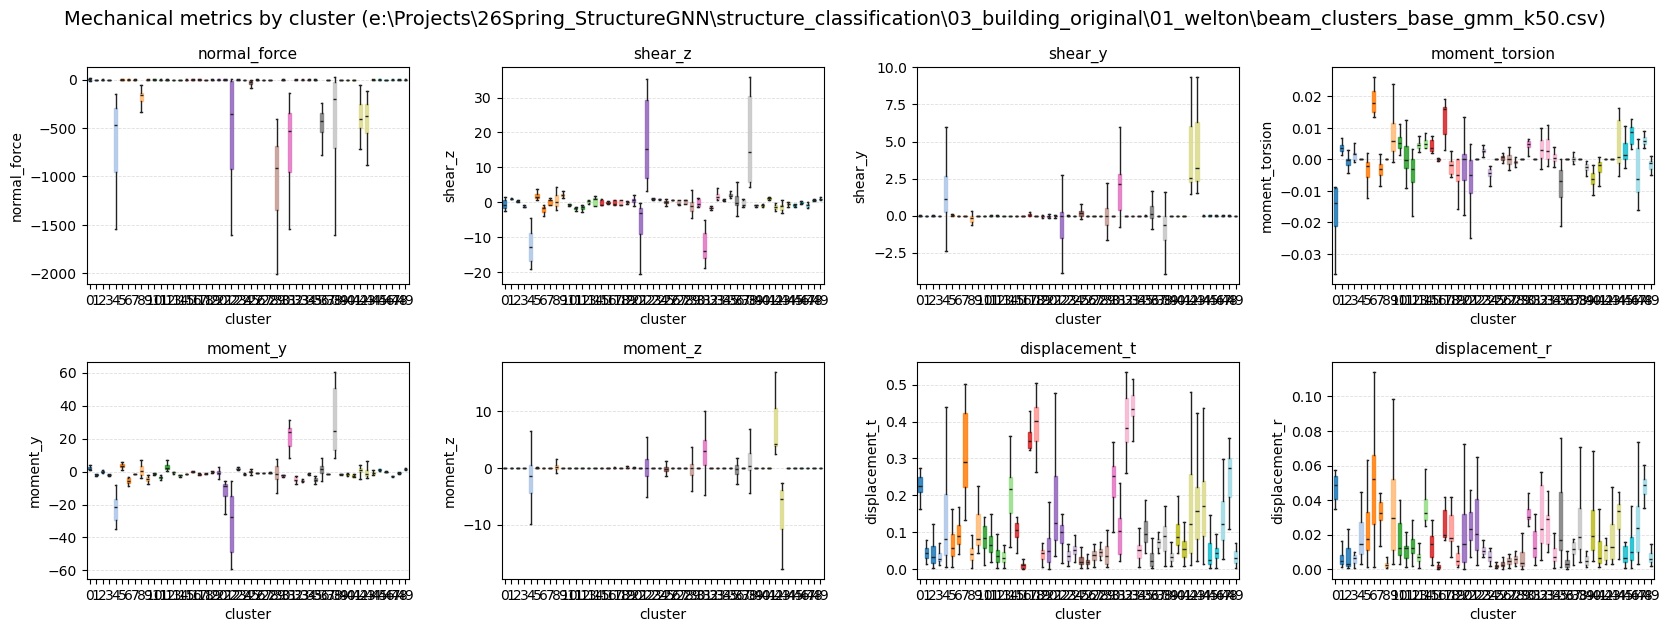

In [59]:
# ---- Compare with baseline ----
df_cmp = load_cluster_merged_df(CLUSTER_FILE_COMPARE)
plot_all_metrics_boxplots_grid(
    df_cmp,
    cluster_to_hex=cluster_to_hex,
    ncols=4,
    showfliers=False,
    use_symlog=False,
    title=f"Mechanical metrics by cluster ({CLUSTER_FILE_COMPARE})",
)
